<a href="https://colab.research.google.com/github/paolamerida2002-dev/Marketing-Analytics-Paola-Merida_1/blob/Tarea_Actividad_2_Grupo_2/Semana_3/breakout_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breakout Room #3 — Identificar los 4 cuadrantes

**Objetivo:**
- Detectar a los clientes que están en los cuatro cuadrantes.
- ¿Lograremos ver en cuáles es necesario invertir?

Esta es la base del experimento real de retención de Starbucks Rewards: 14,000 clientes, la mitad
recibió una oferta de retención (`treatment`), la otra mitad no (`control`) — asignados al azar.
Donde dice **`# TODO`** hay algo para que ustedes completen.


In [1]:
%cd /content
!git clone https://github.com/paolamerida2002-dev/Marketing-Analytics-Paola-Merida_1.git
%cd /content/Marketing-Analytics-Paola-Merida_1

/content
Cloning into 'Marketing-Analytics-Paola-Merida_1'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 55 (delta 19), reused 38 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 2.49 MiB | 5.26 MiB/s, done.
Resolving deltas: 100% (19/19), done.
/content/Marketing-Analytics-Paola-Merida_1


In [4]:
from pathlib import Path

repo = Path("/content/Marketing-Analytics-Paola-Merida_1")

for nombre in ["transactions.csv", "customers.csv", "uplift_experiment.csv"]:
    encontrados = list(repo.rglob(nombre))
    print(f"{nombre}:")
    for archivo in encontrados:
        print(archivo)
    if not encontrados:
        print("No se encontró en el repositorio")

transactions.csv:
/content/Marketing-Analytics-Paola-Merida_1/Semana_3/data/transactions.csv
customers.csv:
/content/Marketing-Analytics-Paola-Merida_1/Semana_3/data/customers.csv
uplift_experiment.csv:
/content/Marketing-Analytics-Paola-Merida_1/Semana_3/data/uplift_experiment.csv


In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("Semana_3/data/uplift_experiment.csv")
print(f"{len(df):,} clientes · {(df['treatment_group']=='treatment').sum():,} tratados · {(df['treatment_group']=='control').sum():,} control")
df.head()


14,000 clientes · 6,904 tratados · 7,096 control


,customer_id,treatment_group,recency_days,frequency,monetary,email_open_rate,responded_90d,value_90d
0,1,control,9,15,437.41,1.000,1,26.24
1,2,control,59,7,159.66,0.217,0,0.00
2,3,control,106,8,172.83,0.300,0,0.00
3,4,treatment,181,1,57.46,0.018,0,0.00
4,5,treatment,146,3,44.61,0.124,0,0.00


## Paso 1 — recuerden la fórmula de "uplift en una línea"

```
uplift(cliente) = P(compra | lo contacto) − P(compra | no lo contacto)
```

El problema: para UN cliente real, solo observamos una de las dos mitades (su contrafactual no
existe — ya lo vimos). La solución práctica: un **T-learner**. Entrenamos DOS modelos separados:

- Un modelo que solo vio clientes **tratados**, para estimar P(compra | lo contacto).
- Un modelo que solo vio clientes de **control**, para estimar P(compra | no lo contacto).

Después, le preguntamos a LOS DOS modelos sobre TODOS los clientes (tratados y de control por
igual) — así cada cliente termina con sus dos probabilidades, aunque en la realidad solo vivió una.


In [6]:
FEATURES = ["recency_days", "frequency", "monetary", "email_open_rate"]

tratados = df[df["treatment_group"] == "treatment"]
control = df[df["treatment_group"] == "control"]

print(f"Entrenamiento del modelo de tratados: {len(tratados):,} filas")
print(f"Entrenamiento del modelo de control:  {len(control):,} filas")


Entrenamiento del modelo de tratados: 6,904 filas
Entrenamiento del modelo de control:  7,096 filas


In [7]:
control.head()

,customer_id,treatment_group,recency_days,frequency,monetary,email_open_rate,responded_90d,value_90d
0,1,control,9,15,437.41,1.000,1,26.24
1,2,control,59,7,159.66,0.217,0,0.00
2,3,control,106,8,172.83,0.300,0,0.00
5,6,control,43,3,167.61,0.461,0,0.00
6,7,control,149,4,23.18,0.086,0,0.00


In [8]:
# TODO: entrenen los dos modelos del T-learner.
# modelo_tratado   se entrena SOLO con las filas de "tratados" (X=FEATURES, y=responded_90d)
# modelo_control  se entrena SOLO con las filas de "control"
# Creamos un modelo para los clientes que recibieron la oferta.

modelo_tratado = LogisticRegression(max_iter=1000)

# El modelo aprende a relacionar las características del cliente
# con su respuesta durante los siguientes 90 días.
modelo_tratado.fit(
    tratados[FEATURES],
    tratados["responded_90d"]
)

# Creamos otro modelo para quienes no recibieron la oferta.
modelo_control = LogisticRegression(max_iter=1000)

# Este modelo aprende con los resultados de los clientes
# que no recibieron la oferta.
modelo_control.fit(
    control[FEATURES],
    control["responded_90d"]
)

LogisticRegression(max_iter=1000)

## Paso 2 — pregúntenle a los DOS modelos sobre TODOS los clientes

Aquí está el truco del T-learner: no importa si un cliente de verdad fue tratado o no, le pedimos
a `modelo_tratado` su probabilidad COMO SI lo hubieran tratado, y a `modelo_control` su
probabilidad COMO SI no lo hubieran tratado.


In [9]:
X_todos = df[FEATURES]

# TODO: calculen p_tratado (probabilidad de responder según modelo_tratado) y
# p_control (probabilidad de responder según modelo_control) para TODOS los clientes.
# Pista: modelo.predict_proba(X_todos)[:, 1] les da la probabilidad de la clase 1.

# Seleccionamos las características de todos los clientes.
X_todos = df[FEATURES]

# Estimamos la probabilidad de compra si recibieran la oferta.
df["p_tratado"] = modelo_tratado.predict_proba(X_todos)[:, 1]

# Estimamos la probabilidad de compra si NO recibieran la oferta.
df["p_control"] = modelo_control.predict_proba(X_todos)[:, 1]

# Calculamos cuánto cambiaría la probabilidad de compra
# gracias a la oferta. Esa diferencia se llama uplift.
df["uplift_estimado"] = df["p_tratado"] - df["p_control"]

# Mostramos los primeros cinco resultados.
df[["p_tratado", "p_control", "uplift_estimado"]].head()


,p_tratado,p_control,uplift_estimado
0,0.934143,0.676138,0.258005
1,0.477361,0.310318,0.167043
2,0.441871,0.268046,0.173825
3,0.131832,0.102107,0.029725
4,0.220318,0.121732,0.098586


## Paso 3 — clasifiquen a cada cliente en uno de los 4 cuadrantes

Usamos la mediana de cada probabilidad como punto de corte entre "alta" y "baja".


In [10]:
corte_tratado = df["p_tratado"].median()
corte_control = df["p_control"].median()

def cuadrante(row):
    alto_t = row["p_tratado"] >= corte_tratado
    alto_c = row["p_control"] >= corte_control
    if alto_t and alto_c:
        return "Sure Thing"
    if alto_t and not alto_c:
        return "Persuadable"
    if not alto_t and alto_c:
        return "Sleeping Dog"
    return "Lost Cause"

df["cuadrante"] = df.apply(cuadrante, axis=1)
df["cuadrante"].value_counts(normalize=True).rename("% de la base").mul(100).round(1)


,% de la base
cuadrante,
Sure Thing,45.2
Lost Cause,45.2
Sleeping Dog,4.8
Persuadable,4.8


## Paso 4 — ¿en cuáles es necesario invertir?

Comparen tres reglas de targeting, igual que en la slide de políticas: contactar al 30% con mayor
RIESGO de no responder (estilo churn) vs. contactar al 30% con mayor UPLIFT ESTIMADO vs. un 30% al
azar. Midan el valor real usando `value_90d`, comparando tratados contra control DENTRO de cada
grupo seleccionado

In [11]:
df.head()

,customer_id,treatment_group,recency_days,frequency,monetary,email_open_rate,responded_90d,value_90d,p_tratado,p_control,uplift_estimado,cuadrante
0,1,control,9,15,437.41,1.000,1,26.24,0.934143,0.676138,0.258005,Sure Thing
1,2,control,59,7,159.66,0.217,0,0.00,0.477361,0.310318,0.167043,Sure Thing
2,3,control,106,8,172.83,0.300,0,0.00,0.441871,0.268046,0.173825,Sleeping Dog
3,4,treatment,181,1,57.46,0.018,0,0.00,0.131832,0.102107,0.029725,Lost Cause
4,5,treatment,146,3,44.61,0.124,0,0.00,0.220318,0.121732,0.098586,Lost Cause


In [12]:
def valor_de_la_politica(seleccionados):
    sel = df.loc[seleccionados]
    valor_tratado = sel.loc[sel["treatment_group"] == "treatment", "value_90d"].mean()
    valor_control = sel.loc[sel["treatment_group"] == "control", "value_90d"].mean()
    return valor_tratado - valor_control, len(sel)

n_contactar = int(len(df) * 0.30)

# Regla 1: al azar
idx_azar = df.sample(n=n_contactar, random_state=42).index
uplift_azar, n_azar = valor_de_la_politica(idx_azar)

# Regla 2: por "riesgo" (al estilo churn) -- aquí lo aproximamos con p_control baja
# (baja probabilidad de comprar sin ayuda = "en riesgo")
idx_riesgo = df.sort_values("p_control").head(n_contactar).index
uplift_riesgo, n_riesgo = valor_de_la_politica(idx_riesgo)

# Regla 3: por uplift estimado (T-learner)
idx_uplift = df.sort_values("uplift_estimado", ascending=False).head(n_contactar).index
uplift_modelo, n_modelo = valor_de_la_politica(idx_uplift)

resultado = pd.DataFrame({
    "regla": ["Al azar", "Por riesgo (estilo churn)", "Por uplift (T-learner)"],
    "clientes_contactados": [n_azar, n_riesgo, n_modelo],
    "valor_incremental_por_cliente": [uplift_azar, uplift_riesgo, uplift_modelo],
})
resultado["valor_incremental_total"] = resultado["valor_incremental_por_cliente"] * resultado["clientes_contactados"]
resultado.round(2)


,regla,clientes_contactados,valor_incremental_por_cliente,valor_incremental_total
0,Al azar,4200,2.91,12238.69
1,Por riesgo (estilo churn),4200,0.30,1264.60
2,Por uplift (T-learner),4200,8.15,34229.38


## Paso 5 — la gráfica: composición del 30% seleccionado por cada regla


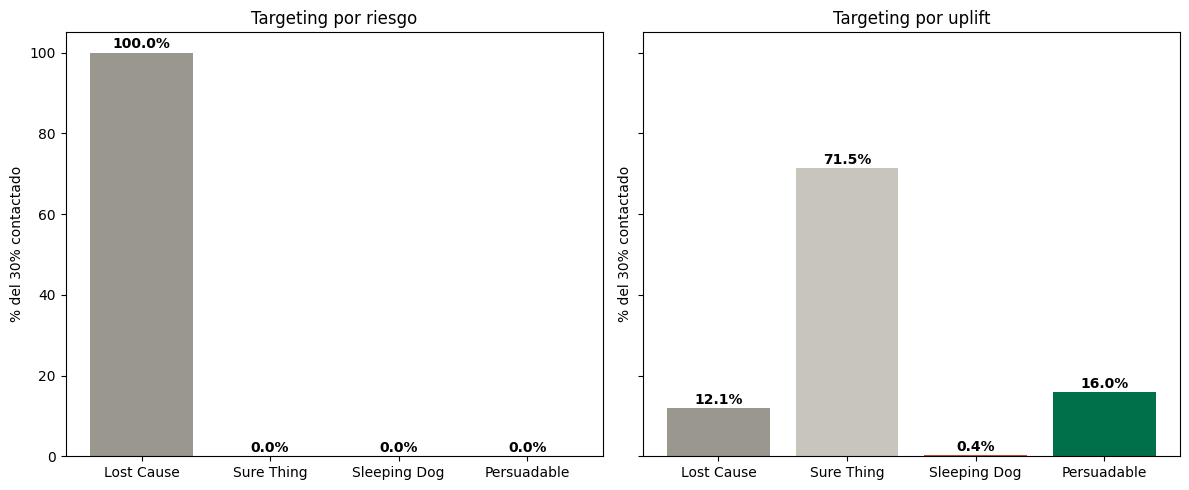

In [13]:
import matplotlib.pyplot as plt

comp_riesgo = df.loc[idx_riesgo, "cuadrante"].value_counts(normalize=True).reindex(
    ["Lost Cause", "Sure Thing", "Sleeping Dog", "Persuadable"]).fillna(0) * 100
comp_uplift = df.loc[idx_uplift, "cuadrante"].value_counts(normalize=True).reindex(
    ["Lost Cause", "Sure Thing", "Sleeping Dog", "Persuadable"]).fillna(0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors = {"Lost Cause": "#9A988E", "Sure Thing": "#C8C6BC", "Sleeping Dog": "#C4512F", "Persuadable": "#00704A"}

for ax, comp, titulo in zip(axes, [comp_riesgo, comp_uplift], ["Targeting por riesgo", "Targeting por uplift"]):
    ax.bar(comp.index, comp.values, color=[colors[c] for c in comp.index])
    ax.set_title(titulo)
    ax.set_ylabel("% del 30% contactado")
    for i, v in enumerate(comp.values):
        ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("composicion_cuadrantes.png", dpi=150)
plt.show()


In [ ]:
# Comparación de "tocar" o "no tocar" a un sleeping dog
sd = df[df["cuadrante"] == "Sleeping Dog"]
sd_t = sd.loc[sd["treatment_group"] == "treatment", "value_90d"].mean()
sd_c = sd.loc[sd["treatment_group"] == "control", "value_90d"].mean()
print(f"Sleeping Dogs: {len(sd):,} ({len(sd)/len(df):.1%} de la base)")
print(f"  valor si tratado=${sd_t:.2f}  valor si control=${sd_c:.2f}  efecto=${sd_t-sd_c:+.2f}")

## Para la Clase

1. ¿Qué regla dejó más valor incremental total: por riesgo o por uplift?
2. Miren la composición del 30% que targetea "por riesgo" — ¿cuántos Sleeping Dogs se colaron ahí?
   Eso es exactamente el costo de confundir "en riesgo" con "vale la pena contactar".
3. Con su propia tabla del Paso 4 en la mano: **¿en qué cuadrante es necesario invertir, y en
   cuál definitivamente NO?**
